# Projectile Motion — Velocity Vectors

A particle is launched with speed $v_0$ at an angle $\theta$ above the horizontal.

The plot shows the particle's **position as time passes** (its trajectory). At each time step, three arrows are drawn from the particle:

- **Blue** — horizontal velocity $v_x$ (stays constant)
- **Green** — vertical velocity $v_y$ (shrinks on the way up, grows downward on the way down, and vanishes at the top)
- **Red** — net velocity $\vec{v} = (v_x, v_y)$ (always tangent to the path)

Change `v0`, `angle`, or `n_steps` in the cell below and re-run to explore.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81  # gravitational acceleration (m/s^2)

# Launch parameters
v0 = 20.0     # initial speed (m/s)
angle = 55.0  # launch angle above the horizontal (degrees)
n_steps = 11  # number of time steps shown on the plot

# Initial velocity components
theta = np.radians(angle)
vx0 = v0 * np.cos(theta)
vy0 = v0 * np.sin(theta)

# Time of flight (particle launched from, and landing at, y = 0)
t_flight = 2 * vy0 / g

# Simulate the motion at each time step
t = np.linspace(0, t_flight, n_steps)
x = vx0 * t
y = vy0 * t - 0.5 * g * t**2

# Velocity at each time step
vx = np.full_like(t, vx0)  # horizontal velocity is constant
vy = vy0 - g * t           # vertical velocity decreases linearly with time

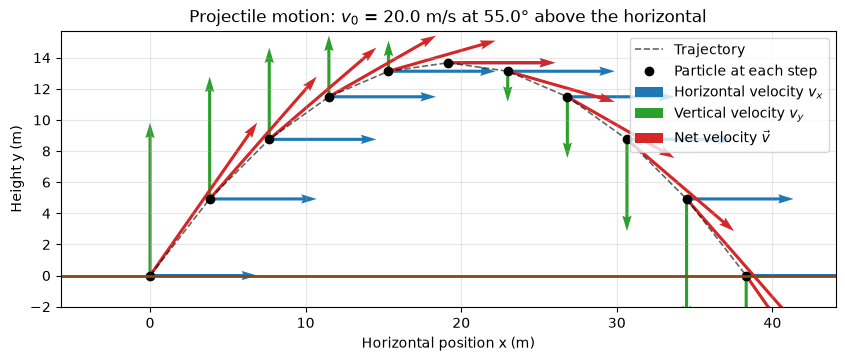

In [2]:
ARROW_SCALE = 0.6  # shrinks the velocity arrows so neighbouring steps don't overlap

fig, ax = plt.subplots(figsize=(10, 7))

# Trajectory and the particle's position at each step
ax.plot(x, y, 'k--', linewidth=1.2, alpha=0.6, label='Trajectory')
ax.plot(x, y, 'o', color='black', markersize=6, label='Particle at each step')

# Three arrows at each step: horizontal, vertical, and net velocity
ax.quiver(x, y, vx * ARROW_SCALE, np.zeros_like(t),
          angles='xy', scale_units='xy', scale=1,
          color='tab:blue', width=0.004, label='Horizontal velocity $v_x$')
ax.quiver(x, y, np.zeros_like(t), vy * ARROW_SCALE,
          angles='xy', scale_units='xy', scale=1,
          color='tab:green', width=0.004, label='Vertical velocity $v_y$')
ax.quiver(x, y, vx * ARROW_SCALE, vy * ARROW_SCALE,
          angles='xy', scale_units='xy', scale=1,
          color='tab:red', width=0.004, label='Net velocity $\\vec{v}$')

# Ground
ax.axhline(0, color='saddlebrown', linewidth=2)

ax.set_aspect('equal')  # equal scale on both axes, so arrow directions are true
ax.margins(0.15)        # leave room for arrows that stick out past the path
ax.set_xlabel('Horizontal position x (m)')
ax.set_ylabel('Height y (m)')
ax.set_title(f'Projectile motion: $v_0$ = {v0} m/s at {angle}° above the horizontal')
ax.grid(alpha=0.3)
ax.legend(loc='upper right')

plt.show()

## Physics used

With no air resistance, the horizontal and vertical motions are independent:

$$
x(t) = v_{x0}\,t \qquad\qquad y(t) = v_{y0}\,t - \tfrac{1}{2} g t^2
$$

$$
v_x(t) = v_{x0} \qquad\qquad v_y(t) = v_{y0} - g t
$$

- $v_x$ never changes — every blue arrow has the same length.
- $v_y$ decreases by $g$ every second — at the top of the path $v_y = 0$, so the green arrow disappears and the red net-velocity arrow is purely horizontal.
- The net velocity $\vec{v} = (v_x, v_y)$ is always tangent to the trajectory.

Air resistance is ignored and $g = 9.81\ \mathrm{m\,s^{-2}}$.